In [1]:
import math
import numpy as np
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model

from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Input, Dense, BatchNormalization
#from IPython.core.display import Image

from typing import List, Tuple

from matplotlib import pyplot as plt


2026-01-30 17:39:04.442361: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 17:39:04.476581: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
##########################################################################################
# Print iterations progress
#https://stackoverflow.com/questions/3173320/text-progress-bar-in-the-console
def printProgressBar (iteration, total, prefix = '', suffix = '', decimals = 1, \
                      length = 100, fill = '█', printEnd = "\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end = printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

##########################################################################################

def finafunction (x: float) -> float:
        
    #return 1.0 / (1.0 + math.exp(-x))  
    return x*x

##########################################################################################

def generate_real_samples(n: int=100, xs:float = -0.5, xf: float = 0.5) -> \
    Tuple[np.ndarray, np.ndarray]:   

    # generate random numbers between xs and xf
    X1 = np.random.rand(n) * (xf - xs) + xs
    #X1 = np.random.rand(n) - 0.5
    X2 = np.asanyarray([finafunction(x) for x in X1])
	# stack arrays
    X1 = X1.reshape(n, 1)
    X2 = X2.reshape(n, 1)
    y = np.ones((n, 1))
    X = np.hstack((X1, X2))

    return X, y

##########################################################################################

def generate_random_samples(n: int=100, xs:float = -0.5, xf: float = 0.5,
                          ys: float = 0.0, yf : float = 0.25) -> \
                            Tuple[np.ndarray, np.ndarray]:   

    # generate random numbers between xs and xf
    X1 = np.random.rand(n) * (xf - xs) + xs
    X2 = np.random.rand(n) * (yf - ys) + ys
	# stack arrays
    X1 = X1.reshape(n, 1)
    X2 = X2.reshape(n, 1)
    y = np.zeros((n, 1))
    X = np.hstack((X1, X2))

    return X, y

##########################################################################################

def discriminator_model (input_length: int) -> tf.keras.Sequential:

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(25, activation='relu', \
                                    kernel_initializer='he_uniform', \
                                    input_dim=input_length))
    #model.add(tf.keras.layers.Dense(15, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', \
                  optimizer='adam', metrics=['accuracy'])

    return model    

##########################################################################################

def generator_model (input_length: int = 5, output_length: int = 2) -> tf.keras.Sequential:

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(15, activation='relu', \
                                    kernel_initializer='he_uniform', \
                                    input_dim=input_length)) 
    #model.add(tf.keras.layers.Dense(15, activation='linear'))
    #model.add(tf.keras.layers.Dense(15, activation='linear'))
    model.add(tf.keras.layers.Dense(output_length, activation='linear'))

    return model

##########################################################################################

def train_discriminator(model : tf.keras.Sequential , n_epochs : int  =1000, \
                        n_batch : int  =128):
    
    half_batch = int(n_batch / 2)
    # run epochs manually
    for i in range(n_epochs):
        # generate real examples
        X_real, y_real = generate_real_samples(n = half_batch)
        model.train_on_batch(X_real, y_real)
        # generate fake examples
        X_fake, y_fake = generate_fake_samples(n = half_batch)
        model.train_on_batch(X_fake, y_fake)
        # evaluate the model
        _, acc_real = model.evaluate(X_real, y_real, verbose=0)
        _, acc_fake = model.evaluate(X_fake, y_fake, verbose=0)
        
        print("Epoch: %6d %10.6f %10.6f"%(i, acc_real, acc_fake))

##########################################################################################

def generate_random_noise(latent_dim : int , n : int) -> np.ndarray: 
    # generate points in the latent space
    x_input = np.random.randn(latent_dim * n)
    # reshape into a batch of inputs for the network
    x_input = x_input.reshape(n, latent_dim)

    return x_input

##########################################################################################

# use the generator to generate n fake examples and plot the results
def generate_fake_samples(generator : tf.keras.Sequential, latent_dim : int , n : int ) \
    -> Tuple[np.ndarray, np.ndarray] :

    # generate points in latent space
    x_input = generate_random_noise(latent_dim, n)
    X = generator.predict(x_input, verbose=0)
    y = np.zeros((n, 1))

    return X, y

##########################################################################################

def define_gan(generator : tf.keras.Sequential , discriminator : tf.keras.Sequential ) \
    -> tf.keras.Sequential:

    #pile up the two models
    discriminator.trainable = False
    model = tf.keras.Sequential()
    model.add(generator)
    model.add(discriminator)
    model.compile(loss='binary_crossentropy', optimizer='adam')
    
    return model

##########################################################################################

def summarize_performance(epoch : int , generator : tf.keras.Sequential , \
                        discriminator : tf.keras.Sequential , \
                        latent_dim : int , n : int =100):
     
	# prepare real samples
	x_real, y_real = generate_real_samples(n)
	# evaluate discriminator on real examples
	_, acc_real = discriminator.evaluate(x_real, y_real, verbose=0)
	# prepare fake examples
	x_fake, y_fake = generate_fake_samples(generator, latent_dim, n)
	# evaluate discriminator on fake examples
	_, acc_fake = discriminator.evaluate(x_fake, y_fake, verbose=0)
	# summarize discriminator performance
	print(epoch, acc_real, acc_fake)
	# scatter plot real and fake data points
	plt.scatter(x_real[:, 0], x_real[:, 1], color='red')
	plt.scatter(x_fake[:, 0], x_fake[:, 1], color='blue')
	plt.show()

##########################################################################################

def train(g_model : tf.keras.Sequential , d_model : tf.keras.Sequential , \
        gan_model : tf.keras.Sequential , latent_dim : int , n_epochs : int =20000, \
        n_batch : int =128, n_eval : int =5000):
    
	# determine half the size of one batch, for updating the discriminator
	half_batch = int(n_batch / 2)
	# manually enumerate epochs
	for i in range(n_epochs):
		# prepare real samples
		x_real, y_real = generate_real_samples(n=half_batch)
		# prepare fake examples
		x_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
		# update discriminator
		d_model.train_on_batch(x_real, y_real)
		d_model.train_on_batch(x_fake, y_fake)
		# prepare points in latent space as input for the generator
		x_gan = generate_random_noise(latent_dim, n_batch)
		# create inverted labels for the fake samples
		y_gan = np.ones((n_batch, 1))
		# update the generator via the discriminator's error
		gan_model.train_on_batch(x_gan, y_gan)
		# evaluate the model every n_eval epochs
		if (i+1) % n_eval == 0:
			summarize_performance(i, g_model, d_model, latent_dim)
               
##########################################################################################

/home/redo/anaconda3/envs/tf_gpu_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


0 0.5199999809265137 0.3400000035762787


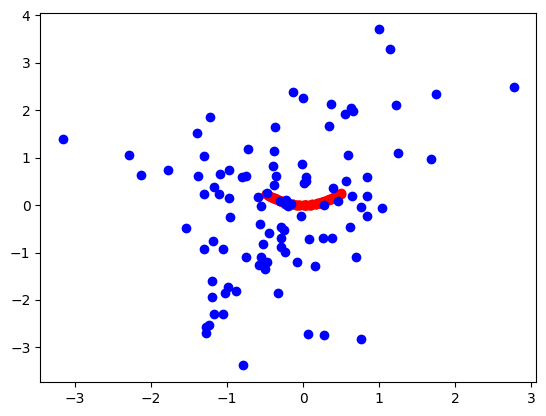

/home/redo/anaconda3/envs/tf_gpu_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


In [ ]:
debug = False
inputdim = 2
randominputdim = 5

if debug:
    real_data = generate_real_samples(100, -0.5, 0.5)

    plt.scatter(real_data[0][:, 0], real_data[0][:, 1])
    plt.show()

# define the discriminator model
discriminator = discriminator_model(inputdim)
# train the discriminator model
#train_discriminator(discriminator, 1000, 128)
generator = generator_model(randominputdim, inputdim)
# test model generation
#generator_fake_samples(generator, randominputdim, 100)
# define the gan model
gan_model = define_gan(generator, discriminator)

summarize_performance(0, generator, discriminator, randominputdim)

train(generator, discriminator, gan_model, randominputdim)

# summarize the model
if debug:
    #discriminator.summary()
    #plot_model(discriminator, to_file='discriminator_plot.png', \
    #           show_shapes=True, show_layer_names=True)
    ann_viz(discriminator, title="Discriminator Model",\
             view=True, filename="dis_model.gv")
    ann_viz(generator, title="Generator Model",\
             view=True, filename="gen_model.gv")
    gan_model.summary()
    plot_model(gan_model, to_file='gan_plot.png', show_shapes=True, show_layer_names=True)
        
